# Ejercicio de programación - Regresión Logística Binaria

En este ejercicio se implementa regresión logística binaria aplicada al dataset **BRFSS 2020** (Behavioral Risk Factor Surveillance System) para predecir el riesgo de **diabetes** (`DIABETE4`).

In [89]:
import numpy as np
import pandas as pd
import warnings
warnings.filterwarnings('ignore')
from matplotlib import pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
print("✓ Librerías científicas de Python inicializadas.")

✓ Librerías científicas de Python inicializadas.


## 1. Carga y Preprocesamiento de Datos

Se utiliza el dataset **BRFSS 2020**. La variable dependiente es `DIABETE4` (¿Alguna vez le dijeron que tiene diabetes?):
- `1` → Sí tiene diabetes
- `2`, `3`, `4` → No (pre-diabetes, solo en embarazo, o no)

La siguiente celda carga los datos **exactamente igual** al notebook de referencia `healthcare-risk-prediction`:

##Definición de X e Y

- **Y** (variable dependiente): `DIABETE4` → 1 = tiene diabetes, 0 = no tiene diabetes
- **X** (variables independientes): los demás predictores disponibles en el dataset

| Variable | Descripción |
|---|---|
| `INCOME2` | Nivel de ingresos |
| `_BMI5` | Índice de masa corporal |
| `_RFHLTH` | Salud general |
| `_PHYS14D` | Días con problemas físicos |
| `_MENT14D` | Días con problemas mentales |
| `CHECKUP1` | Último chequeo médico |
| `MARITAL` | Estado civil |
| `EDUCA` | Nivel educativo |
| `BIRTHSEX` | Sexo |
| `_RACE` | Raza |
| `_STATE` | Estado |
| `VETERAN3` | Veterano |
| `EMPLOY1` | Situación laboral |
| `HLTHPLN1` | Tiene plan de salud |

In [90]:
# Cargar dataset
# df = pd.read_csv('/content/drive/MyDrive/SIS 420/LAB/data/2_brfss2020.csv', low_memory=False)

df=pd.read_csv('../Database/2_brfss2020.csv')
data = df[df['DIABETE4'].isin([1, 3])].copy()
X = data[['MARITAL', 'EDUCA', 'INCOME2', '_BMI5', '_RACE','EMPLOY1', '_RFHLTH', '_PHYS14D', '_MENT14D', 'CHECKUP1']].copy()
y = data['DIABETE4'].map({1: 1,3: 0})

In [91]:
# Reemplazar códigos inválidos por NaN
X = X.replace({
    '_PHYS14D': {9: np.nan},
    '_MENT14D': {9: np.nan},
    'MARITAL': {9: np.nan},
    'EDUCA': {9: np.nan},
    'EMPLOY1': {9: np.nan},
    '_RFHLTH': {9: np.nan},
    'CHECKUP1': {7: np.nan, 9: np.nan},
    'INCOME2': {77: np.nan, 99: np.nan}
})

# Ajustar escala real del IMC
X['_BMI5'] = X['_BMI5'] / 100

# Imputación: mediana para numéricas, moda para categóricas
num = ['_BMI5','EDUCA','INCOME2','_PHYS14D','_MENT14D','CHECKUP1']
cat = ['MARITAL','_RACE','EMPLOY1','_RFHLTH']

X[num] = X[num].fillna(X[num].median())
X[cat] = X[cat].fillna(X[cat].mode().iloc[0])

# Codificar categóricas y escalar numéricas
X = pd.get_dummies(X, columns=cat, drop_first=True, dtype=int)


### 1.2 Visualizar los Datos

Antes de implementar el algoritmo, se visualizan los datos. Se grafica la distribución de la variable objetivo y la relación entre dos variables clave (Edad y BMI) diferenciando por clase.

Se completará el código en `plotData` para que muestre una figura donde los ejes son dos variables predictoras; los ejemplos positivos y negativos se muestran con diferentes marcadores.

In [92]:
def plotData(X, y, col1, col2):

    pos = y == 1   # Diabetes
    neg = y == 0   # No Diabetes

    plt.figure(figsize=(8,6))

    plt.scatter(
        X.loc[pos, col1],
        X.loc[pos, col2],
        marker='*',
        s=40,
        label='Diabetes'
    )

    plt.scatter(
        X.loc[neg, col1],
        X.loc[neg, col2],
        marker='o',
        s=20,
        label='No Diabetes'
    )

    plt.xlabel(col1)
    plt.ylabel(col2)
    plt.legend()
    plt.grid(True)
    plt.show()

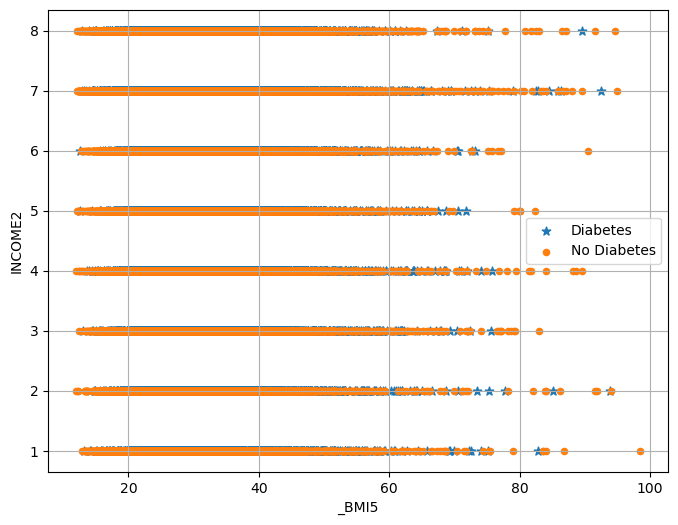

In [93]:
plotData(X, y, '_BMI5', 'INCOME2')

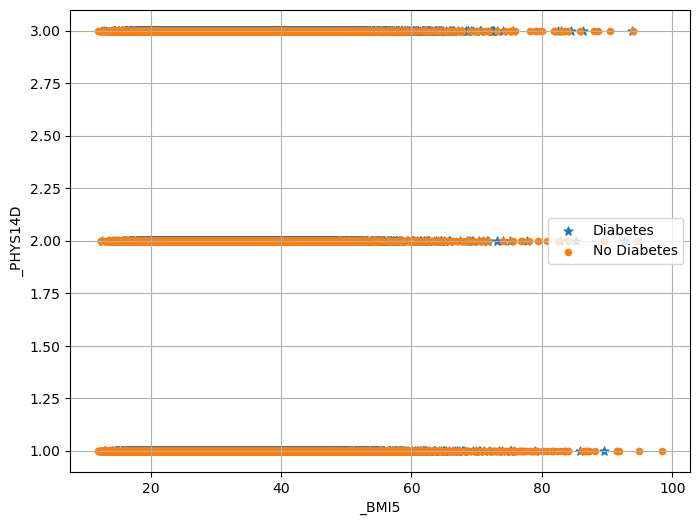

In [94]:
plotData(X, y, '_BMI5', '_PHYS14D')

In [95]:
# Separar entrenamiento y prueba
X_train, X_test, y_train, y_test = train_test_split(X, y,test_size=0.2,random_state=42,stratify=y)

# Escalar solo variables numéricas
scaler = StandardScaler()

X_train[num] = scaler.fit_transform(X_train[num])
X_test[num] = scaler.transform(X_test[num])

# Convertir a matrices numpy
X_train_np = X_train.values
X_test_np = X_test.values
# Ensure y_train_np and y_test_np are 1D arrays
y_train_np = y_train.values
y_test_np = y_test.values

## 2. Implementación de la Regresión Logística

### 2.1 Función Sigmoidea

La hipótesis para la regresión logística se define como:

$$ h_\theta(x) = g(\theta^T x) $$

donde la función $g$ es la función sigmoidea:

$$g(z) = \frac{1}{1+e^{-z}}$$

Para valores positivos grandes de `z` el resultado debe ser cercano a 1; para valores negativos grandes, cercano a 0; y `sigmoid(0) = 0.5`.

In [103]:
def sigmoid(z):
    # Calcula la sigmoide de una entrada z
    # convierte la intrada a un arreglo numpy
    z = np.array(z)

    g = np.zeros(z.shape)

    g = 1 / (1 + np.exp(-z))

    return g

### 2.2 Función de Costo y Gradiente

Antes de continuar, se agrega el término de intercepción (columna de unos) a X.

La función de costo en regresión logística es:

$$ J(\theta) = \frac{1}{m} \sum_{i=1}^{m} \left[ -y^{(i)} \log\left(h_\theta(x^{(i)})\right) - \left(1-y^{(i)}\right) \log\left(1-h_\theta(x^{(i)})\right) \right] $$

Y el gradiente es:

$$ \frac{\partial J(\theta)}{\partial \theta_j} = \frac{1}{m} \sum_{i=1}^{m} \left( h_\theta(x^{(i)}) - y^{(i)} \right) x_j^{(i)} $$

In [102]:
# Configurar la matriz adecuadamente, y agregar una columna de unos que corresponde al termino de intercepción.
# 4. Agregar columna de unos para theta_0
X_train_np = np.c_[np.ones(X_train_np.shape[0]), X_train_np]
X_test_np = np.c_[np.ones(X_test_np.shape[0]), X_test_np]

In [104]:
def calcularCosto(theta, X, y):
    # Inicializar algunos valores utiles
    m = y.size  # numero de ejemplos de entrenamiento

    J = 0
    h = sigmoid(X.dot(theta.T))
    J = (1 / m) * np.sum(-y.dot(np.log(h)) - (1 - y).dot(np.log(1 - h)))

    return J

In [105]:
def descensoGradiente(theta, X, y, alpha, num_iters):
    # Inicializa algunos valores
    m = y.shape[0] # numero de ejemplos de entrenamiento

    # realiza una copia de theta, el cual será acutalizada por el descenso por el gradiente
    theta = theta.copy()
    J_history = []

    for i in range(num_iters):
        h = sigmoid(X.dot(theta.T))
        theta = theta - (alpha / m) * (h - y).dot(X)

        J_history.append(calcularCosto(theta, X, y))
    return theta, J_history

In [106]:
# Elegir algun valor para alpha (probar varias alternativas)
alpha = 0.1
num_iters = 4000

# inicializa theta con el tamaño correcto para X_train_np (incluyendo el término de intercepción)
theta = np.zeros(X_train_np.shape[1])
# Ejecuta el descenso por el gradiente usando los datos de entrenamiento preparados
theta, J_history = descensoGradiente(theta, X_train_np, y_train_np, alpha, num_iters)

print("Costo final:", J_history[-1])
print("Theta final:", theta.shape)

Costo final: 0.3328406147261641
Theta final: (28,)


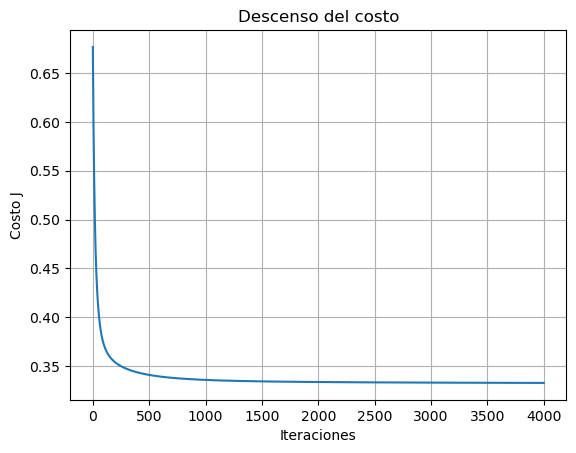

In [107]:
plt.plot(J_history)
plt.xlabel("Iteraciones")
plt.ylabel("Costo J")
plt.title("Descenso del costo")
plt.grid(True)
plt.show()

In [108]:
def predecir(theta, X):
    prob = sigmoid(X @ theta)
    return (prob >= 0.5).astype(int)

y_pred = predecir(theta, X_test_np)

accuracy = np.mean(y_pred == y_test_np) * 100
print("Accuracy:", accuracy)

Accuracy: 86.71369102682701


In [109]:
from sklearn.metrics import mean_squared_error

# Probabilidades estimadas
Y_prob = sigmoid(X_test_np @ theta)

# Error Cuadrático Medio
mse = mean_squared_error(y_test_np, Y_prob)

print("\nMSE:", mse)

# DataFrame de resultados
resultados = pd.DataFrame({
    'Valor_Real': y_test_np.flatten(),
    'Probabilidad': Y_prob.flatten(),
    'Prediccion': y_pred.flatten()
})

print("\nPrimeras filas del DataFrame:")
print(resultados.head(10))


MSE: 0.10095092031465926

Primeras filas del DataFrame:
   Valor_Real  Probabilidad  Prediccion
0           0      0.066251           0
1           0      0.032977           0
2           0      0.048823           0
3           0      0.106774           0
4           0      0.137335           0
5           0      0.405337           0
6           0      0.077334           0
7           0      0.306720           0
8           0      0.130957           0
9           0      0.018529           0


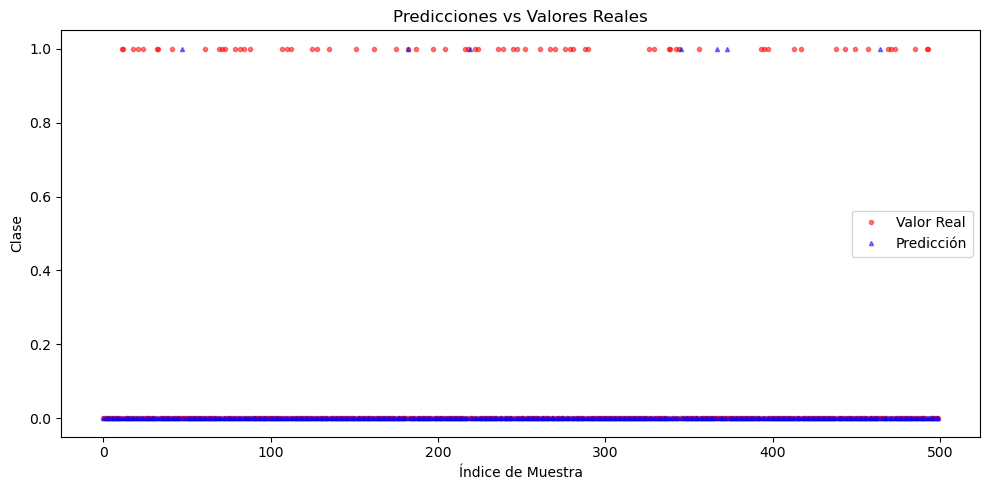

In [110]:
plt.figure(figsize=(10,5))

plt.plot(
    resultados['Valor_Real'].values[:500],
    'ro',
    label='Valor Real',
    alpha=0.5,
    markersize=3
)

plt.plot(
    resultados['Prediccion'].values[:500],
    'b^',
    label='Predicción',
    alpha=0.5,
    markersize=3
)

plt.xlabel('Índice de Muestra')
plt.ylabel('Clase')
plt.title('Predicciones vs Valores Reales')
plt.legend()
plt.tight_layout()
plt.show()